In [1]:
%matplotlib widget
from mtpy import MT, MTData
from mtpy.modeling import StructuredGrid3D
from pathlib import Path



In [2]:
edi_path = Path(r"c:\Users\jpeacock\OneDrive - DOI\MTData\CL2025\mth5\EDI_Files_aurora_geomag_rr_boulder")

In [3]:
md = MTData()
md.add_station(list(edi_path.glob("*.edi")))

In [5]:
mdr = md.rotate(-13.3, inplace=False)

In [9]:
for mt_obj in mdr.values():
    mt_obj.write(
        Path(
            r"c:\Users\jpeacock\OneDrive - DOI\MTData\CL2025\EDI_Files_geomagnetic_north"
        ).joinpath(f"{mt_obj.station}_rotated.edi")
    )

26:01:26T16:26:45 | WARNING | line:784 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because HTTPSConnectionPool(host='basemap.nationalmap.gov', port=443): Max retries exceeded with url: /arcgis/rest/services/USGSTopo/MapServer/tile/11/778/324 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1032)')))


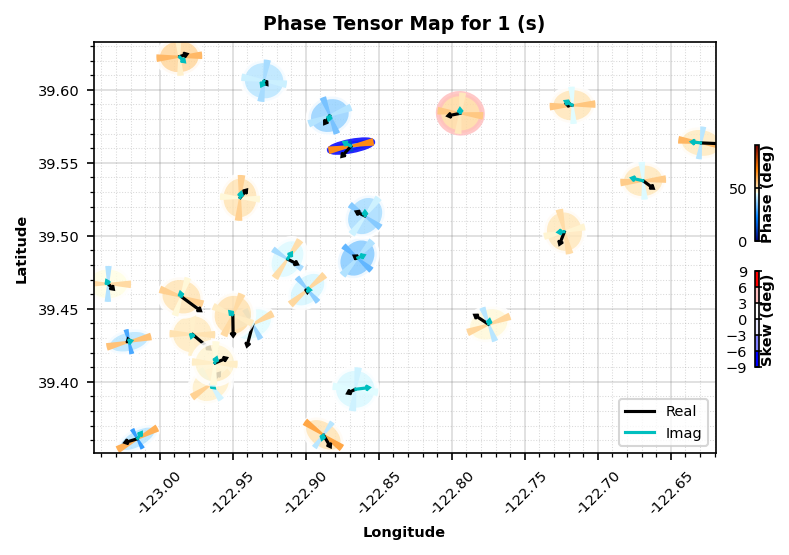

In [14]:
ptm = mdr.plot_phase_tensor_map(ellipse_size=.015, arrow_size=.07, plot_tipper="yri")

26:01:26T16:28:15 | WARNING | line:784 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because HTTPSConnectionPool(host='basemap.nationalmap.gov', port=443): Max retries exceeded with url: /arcgis/rest/services/USGSTopo/MapServer/tile/11/778/324 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1032)')))


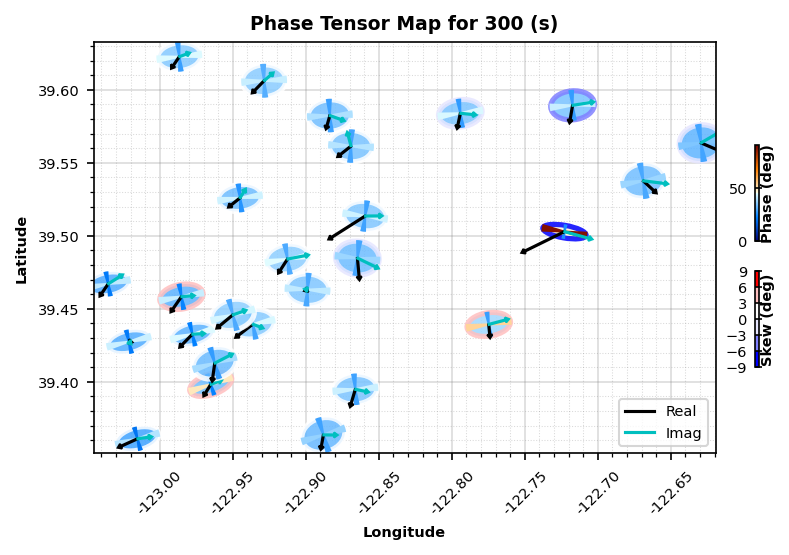

In [17]:
ptm.plot_period = 300
ptm.redraw_plot()

In [51]:
save_path = Path(r"c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\inv_06_topo")

In [60]:
md = MTData()
md.from_modem(r"c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\inv_06_topo\cl_modem_data_z03_t02.dat")

md._center_elev = 0
md._center_lat = None
md._center_lon = None
md.compute_relative_locations()
print(md.center_point)

MT Location: 
--------------------
  Latitude (deg):   39.136474
  Longitude (deg):  -122.777992
  Elevation (m):    0.0000
  Datum crs:        EPSG:4326

  Easting (m):      519187.097
  Northing (m):     4331944.939
  UTM crs:          EPSG:32610

  Model Easting (m):      519187.097
  Model Northing (m):     4331944.939
  Model Elevation (m):    0.000
  Profile Offset (m):     0.000


Structured3DMesh Model Object:
--------------------
	Number of stations = 169
	Mesh Parameter: 
		cell_size_east:    500
		cell_size_north:   500
		pad_east:          7
		pad_north:         7
		pad_num:           4
		z1_layer:          30
		z_target_depth:    70000
		n_layers:          85
		n_air_layers:      42
		res_initial_value: 50
	Dimensions: 
		e-w: 175
		n-s: 243
		z:   86 (without 7 air layers)
	Extensions: 
		e-w:  300800.0 (m)
		n-s:  300000.0 (m)
		0-z:  393372.7 (m)
--------------------


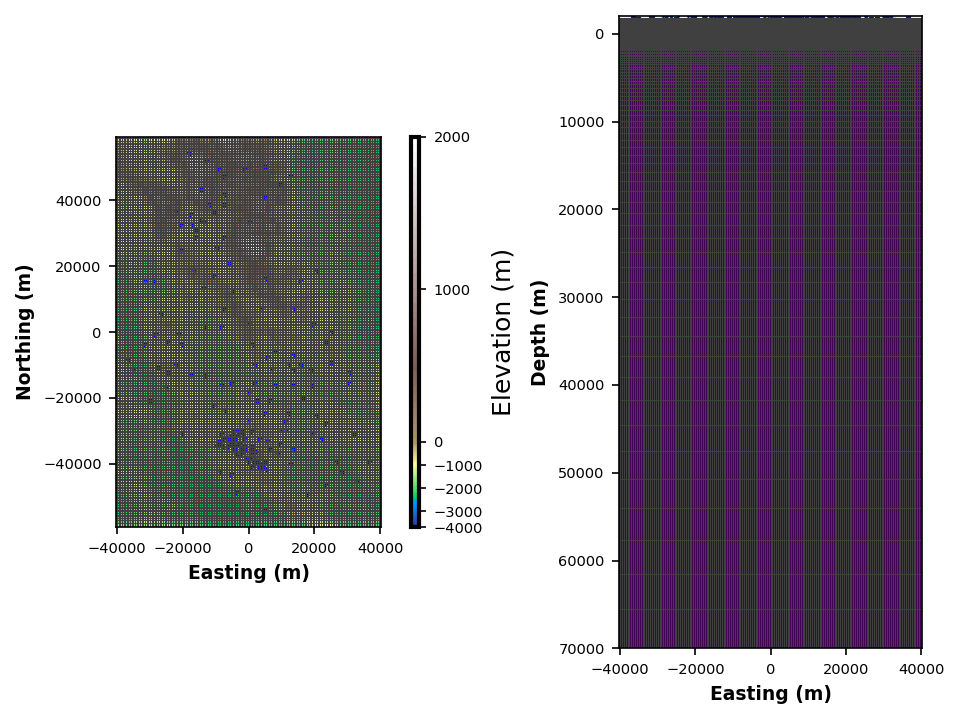

Plotting PlotMesh

In [61]:
mod_obj = StructuredGrid3D()
mod_obj.station_locations = md.station_locations
mod_obj.center_point = md.center_point
mod_obj.cell_size_east = 500
mod_obj.cell_size_north = 500
mod_obj.pad_east = 7
mod_obj.pad_north = 7
mod_obj.pad_num = 4
mod_obj.ew_ext = 300000
mod_obj.ns_ext = 300000
mod_obj.z_bottom = 300000
mod_obj.z_target_depth = 70000
mod_obj.pad_z = 6
mod_obj.n_air_layers = 42
mod_obj.n_layers = 85
mod_obj.z1_layer = 30
mod_obj.pad_stretch_v = 1.8
mod_obj.z_layer_rounding = 1
mod_obj.res_initial_value = 50

# --> here is where you can rotate the mesh
mod_obj.mesh_rotation_angle = 0

mod_obj.make_mesh()
# mod_obj.plot_mesh()

# mod_obj.write_model_file(save_path=save_path,
#                         model_fn_basename="{0}_sm02.rho".format(fn_stem))

## =============================================================================
## Add topography
## =============================================================================
topo_fn = Path(r"c:\Users\jpeacock\OneDrive - DOI\ArcGIS\westcoast_etopo.asc")
mod_obj.add_topography_to_model(
    topo_fn, airlayer_type="constant", max_elev=1860
)
mod_obj.plot_mesh()


In [62]:

mod_obj.to_modem(
    save_path=save_path,
    model_fn_basename="cl_sm02_topo.rho",
)


26:01:27T11:10:40 | INFO | line:830 |mtpy.modeling.structured_mesh_3d | to_modem | Wrote file to: c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\inv_06_topo\cl_sm02_topo.rho


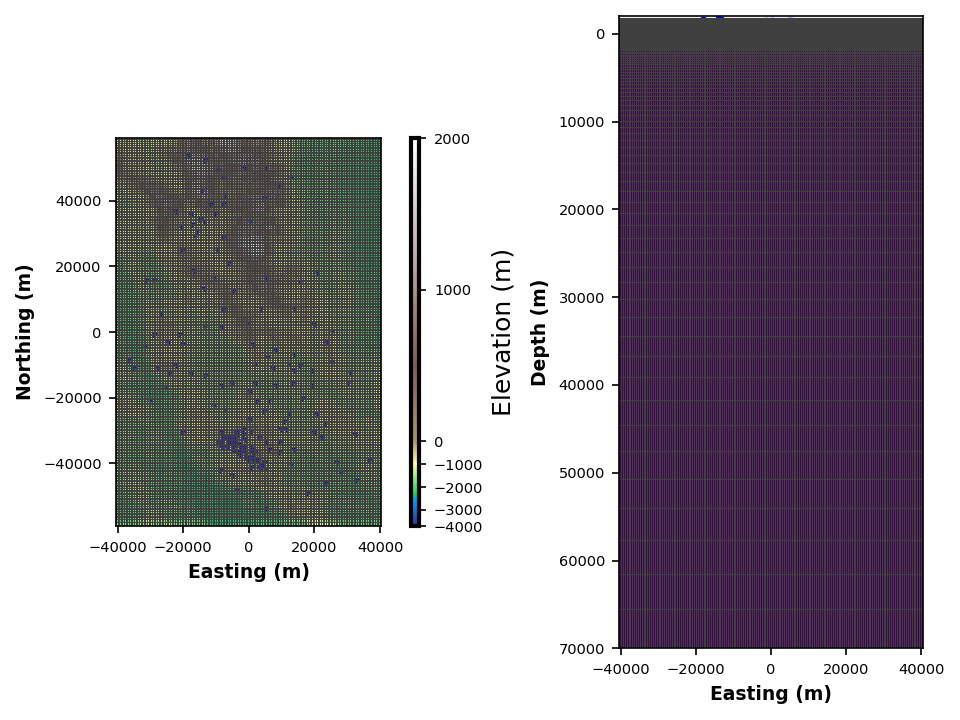

26:01:27T11:10:58 | WARNING | line:571 |mtpy.modeling.modem.data | _check_for_too_small_values | Found values in t_zx smaller than 1e-10 1137 times. Setting to nan
26:01:27T11:10:58 | WARNING | line:571 |mtpy.modeling.modem.data | _check_for_too_small_values | Found values in t_zy smaller than 1e-10 1137 times. Setting to nan
26:01:27T11:11:00 | INFO | line:652 |mtpy.modeling.modem.data | write_data_file | Wrote ModEM data file to c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\inv_06_topo\cl_modem_data_topo_z03_t02_tec.dat


ModEM Data Object:
	Number of impedance stations: 169
	Number of tipper stations: 169
	Number of phase tensor stations: 169
	Number of periods:  23
	Period range (s):  
		Min: 0.0033333
		Max: 2048
	Rotation angle:     0.0
	Data center:        
		Latitude:   39.1365 deg 	Northing: 4331944.9394 m
		Longitude: -122.7780 deg 	Easting: 519187.0974 m
		Datum epsg: 4326			UTM epsg:   32610
		Elevation:  0.0 m
	Impedance data:     True
	Tipper data:        True
	Inversion Mode:   Full_Impedance, Full_Vertical_Components

In [63]:

md.center_stations(mod_obj)
md.project_stations_on_topography(mod_obj)

mod_obj.station_locations = md.station_locations
mod_obj.plot_mesh(fig_num=3)

md.to_modem(save_path / "cl_modem_data_topo_z03_t02_tec.dat")


In [64]:

# ==============================================================================
# make the covariance file
# ==============================================================================
from mtpy.modeling.modem import Covariance
cov = Covariance(grid_dimensions=mod_obj.res_model.shape)
cov.smoothing_east = 0.5
cov.smoothing_north = 0.5
cov.smoothing_z = 0.5
cov.smoothing_num = 1

cov.write_covariance_file(
    save_path / "covariance.cov", 

)

# mod_obj.write_vtk_file(
#     vtk_save_path=save_path, vtk_fn_basename="{0}_sm_topo".format(fn_stem)
# )
# data_obj.write_vtk_station_file(
#     vtk_save_path=save_path, vtk_fn_basename="{0}_stations".format(fn_stem)
# )

# mod_obj.print_mesh_params()
# mod_obj.print_model_file_summary()

26:01:27T11:11:06 | INFO | line:232 |mtpy.modeling.modem.convariance | write_covariance_file | Wrote covariance file to c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\inv_06_topo\covariance.cov


In [65]:
s2 = StructuredGrid3D()
s2.from_modem(save_path / "cl_sm02_topo.rho")

md2 = MTData()
md2.from_modem(save_path / "cl_modem_data_topo_z03_t02_tec.dat")
md2.project_stations_on_topography(s2)
md2.to_modem(save_path / "cl_modem_data_topo_z03_t02_tec_02.dat")

md2.z_model_error.error_value = 10
md2.z_model_error.error_type = "eigen"
md2.t_model_error.error_value = 0.03

md2.to_modem(save_path / "cl_modem_data_topo_z10_tec.dat", inv_mode="2")
md2.to_modem(save_path / "cl_modem_data_topo_t02_tec.dat", inv_mode="5")

26:01:27T11:11:43 | WARNING | line:571 |mtpy.modeling.modem.data | _check_for_too_small_values | Found values in t_zx smaller than 1e-10 1137 times. Setting to nan
26:01:27T11:11:43 | WARNING | line:571 |mtpy.modeling.modem.data | _check_for_too_small_values | Found values in t_zy smaller than 1e-10 1137 times. Setting to nan
26:01:27T11:11:45 | INFO | line:652 |mtpy.modeling.modem.data | write_data_file | Wrote ModEM data file to c:\Users\jpeacock\OneDrive - DOI\ClearLake\modem_inv\inv_06_topo\cl_modem_data_topo_z03_t02_tec_02.dat
26:01:27T11:12:03 | WARNING | line:571 |mtpy.modeling.modem.data | _check_for_too_small_values | Found values in t_zx smaller than 1e-10 1137 times. Setting to nan
26:01:27T11:12:03 | WARNING | line:571 |mtpy.modeling.modem.data | _check_for_too_small_values | Found values in t_zy smaller than 1e-10 1137 times. Setting to nan
26:01:27T11:12:05 | INFO | line:652 |mtpy.modeling.modem.data | write_data_file | Wrote ModEM data file to c:\Users\jpeacock\OneDrive 

ModEM Data Object:
	Number of impedance stations: 169
	Number of tipper stations: 169
	Number of phase tensor stations: 169
	Number of periods:  23
	Period range (s):  
		Min: 0.0033333
		Max: 2048
	Rotation angle:     0.0
	Data center:        
		Latitude:   39.1365 deg 	Northing: 4331944.8898 m
		Longitude: -122.7780 deg 	Easting: 519187.0873 m
		Datum epsg: 4326			UTM epsg:   32610
		Elevation:  -1862.0 m
	Impedance data:     True
	Tipper data:        True
	Inversion Mode:   Full_Vertical_Components

In [66]:
md2.station_locations.elevation.max()

np.float64(1818.999)

In [44]:
1530/30

51.0

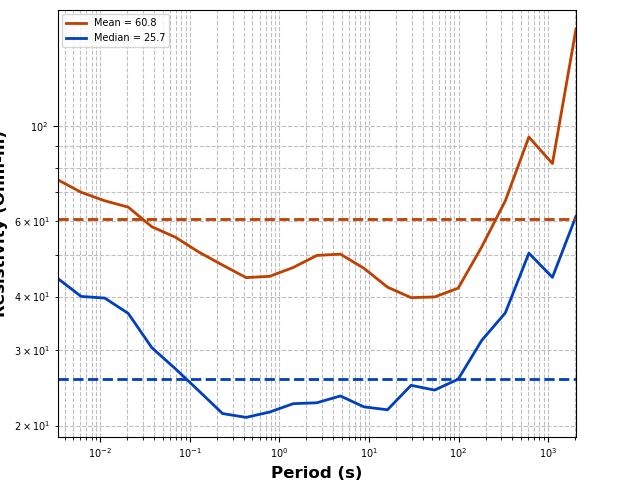

In [59]:
md.estimate_starting_rho()